<div align="center">

# Machine Learning
## Regresión Logistica
<br><br><br><br><br>
---

### **Autor:** Anderson Jawarlan Vargas Ruiz
### **Profesor:** Danny Aldemar Jimenez Martin 
<br><br><br><br><br>
### **Universidad:** Fundación universitaria UNICAFAM
### **Facultad:** Ingeniería
### **Curso:** Inteligencia artificial II 5to Semestre
<br><br><br><br><br>
<br><br><br><br><br>
<p><center> Bogotá D.C
<p><center> 28 de Marzo del 2026

<br><br><br><br><br><br><br><br><br><br>

---

## **Resumen**
<p style="text-align: justify">Este documento contiene el desarrollo de ejercicios prácticos de machine learning y regresión polinomica, incluyendo representaciones gráficas mediante graficos de dispersión con operaciones sobre modelo de entrenamiento y error cuadratico medio. Se carga dataset mencionados en clase.

</div>

## Librerias

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

from sklearn.model_selection import train_test_split #Regresión Multiple
from sklearn.datasets import load_digits #Data Sets
from sklearn.linear_model import LogisticRegression #Regresión logistica
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #Matriz de Confución
from sklearn.preprocessing import MinMaxScaler # Nos sirve para escalar los datos (Como la campana de Gaus)
from sklearn.metrics import accuracy_score #Exactitud del modelo

In [2]:
pd.set_option("display.max_columns", None) # Mostrar todas las columnas
pd.set_option("display.max_colwidth", None)# Ajustar el ancho de las columnas (para no cortar texto)
pd.set_option("display.width", None) # Evitar que se corte horizontalmente

## Estilos para graficos de plotly

In [3]:
# Función para Generar estilos en los graficos
def Estilos(fig):
    fig.update_layout(
        template='plotly_dark',
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='#111827',
        font=dict(color='white')
    )
    
    try:
        fig.update_traces(
            marker_line_color='rgb(8,48,107)',
            marker_line_width=1.5, 
            opacity=0.7
        )
    except Exception:
        try:
            fig.update_traces(opacity=0.7)
        except:
            pass

# Ejercicio # 1 - Digitos para imagenes del 0 - 9

## Datos

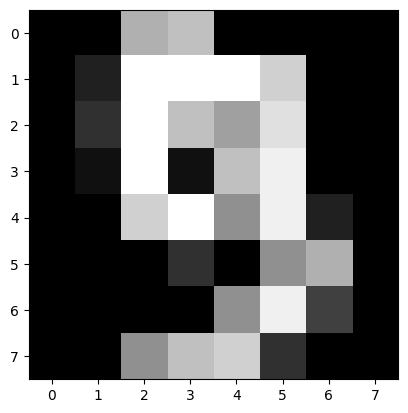

In [4]:
Digitos = load_digits()
Imagen = np.reshape(Digitos.data[9], (8,8))
plt.imshow(Imagen, cmap="gray")

## Entrenamiento del Modelo

In [5]:
x_train, x_test ,y_train, y_test = train_test_split(Digitos.data,Digitos.target,test_size=0.2, random_state=42)
Modelo = LogisticRegression()
Modelo.fit(x_train, y_train)
y_Pred = Modelo.predict(x_test)

C:\Users\jawar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Matriz de confución

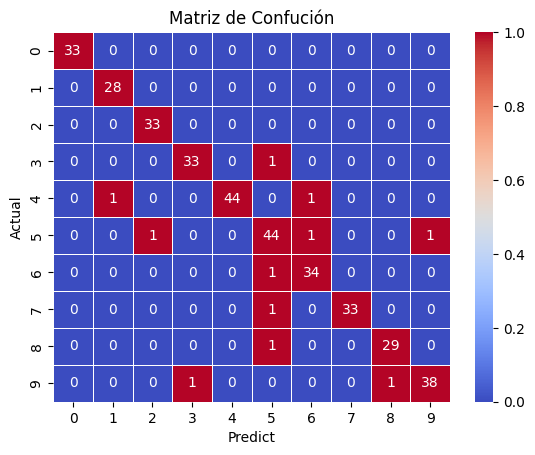

In [6]:
Matriz_Confucion = confusion_matrix(y_test, y_Pred)
sns.heatmap(
    Matriz_Confucion,
    annot=True, 
    cmap="coolwarm", 
    linewidths=0.7, 
    vmin=0, 
    vmax=1
)
plt.title("Matriz de Confución")
plt.ylabel("Actual")
plt.xlabel("Predict")
plt.show()

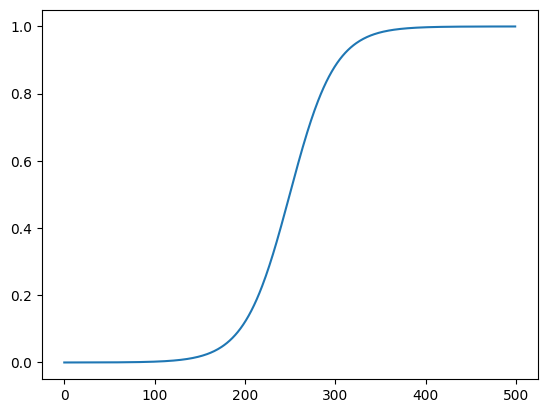

In [7]:
x = np.linspace(-10,10, 500)
funcion = 1 / (1+ np.exp(-x))
plt.plot(funcion)

# Ejercicio # 2 - Base de Kaggle, información de usuarios de telefonia

In [8]:
### Importamos de la tabla
Data_Kaggle = pd.read_csv("../Bases/WA_Fn-UseC_-Telco-Customer-Churn.csv")

### Traducción de campos y Datos

In [9]:
# Traducción de campos
Campos_Trad = {
    'customerID':'ID de cliente',
    'gender':'Género',
    'SeniorCitizen':'Persona mayor',
    'Partner':'Socio',
    'Dependents':'Dependientes',
    'tenure':'Mandato',
    'PhoneService':'Servicio telefónico',
    'InternetService':'Servicio de Internet',
    'MultipleLines':'Múltiples líneas',
    'OnlineSecurity':'Seguridad en línea',
    'OnlineBackup':'Copia de seguridad en línea',
    'DeviceProtection':'Protección de dispositivos',
    'TechSupport':'Soporte técnico',
    'StreamingTV':'Televisión en streaming',
    'StreamingMovies':'Streaming de películas',
    'Contract':'Contrato',
    'PaperlessBilling':'Facturación sin papel',
    'PaymentMethod':'Método de Pago',
    'MonthlyCharges':'Cargos mensuales',
    'TotalCharges':'TotalCargos',
    'Churn':'Cancelación'
}
Data_Kaggle = Data_Kaggle.rename(columns=Campos_Trad)

# Traduccipon de Datos categoricos
Traduce_Datos_Categoricos = {
    "Género":{"Female":"Femenino","Male":"Masculino"},
    "Múltiples líneas":{"No phone service":"Sin servicio Telefonico","Yes":"Si"},
    "Seguridad en línea":{"No internet service":"Sin servicio de internet","Yes":"Si"},
    "Copia de seguridad en línea":{"No internet service":"Sin servicio de internet","Yes":"Si"},
    "Protección de dispositivos":{"No internet service":"Sin servicio de internet","Yes":"Si"},
    "Televisión en streaming":{"No internet service":"Sin servicio de internet","Yes":"Si"},
    "Soporte técnico":{"No internet service":"Sin servicio de internet","Yes":"Si"},
    "Streaming de películas":{"No internet service":"Sin servicio de internet","Yes":"Si"},
    "Servicio de Internet":{"Fiber optic":"Fibra Optica"},
    "Contrato":{"Month-to-month":"Mes a Mes","One year":"1 Año", "Two year":"2 Años"},
    "Método de Pago": {
        "Electronic check":"Cheque electrónico",
        "Mailed check":"Cheque enviado por correo",
        "Bank transfer (automatic)":"Transferencia bancaria (automática)",
        "Credit card (automatic)":"Tarjeta de crédito (automática)"
    },
    # Solo Si
    "Socio":{"Yes":"Si"},
    "Dependientes":{"Yes":"Si"},
    "Servicio telefónico":{"Yes":"Si"},
    "Facturación sin papel":{"Yes":"Si"},
    "Cancelación":{"Yes":"Si"}
}

for columna, traducciones in Traduce_Datos_Categoricos.items():
    if columna in Data_Kaggle.columns:
        Data_Kaggle[columna] = Data_Kaggle[columna].replace(traducciones)


### Analisis y limpieza

In [10]:
Data_Kaggle['TotalCargos'] = pd.to_numeric(Data_Kaggle['TotalCargos'], errors='coerce')

#Validación de datos nullos:
print(Data_Kaggle.isnull().sum())
print(f"\nTotal registros con null: {len(Data_Kaggle)}")
Data_Kaggle.dropna(inplace=True)
print(f"Total registros sin null: {len(Data_Kaggle)}")

#Campos inecesarios #Quitamos Datos que no vamos a utilizar
Data_Kaggle.drop(columns={"ID de cliente", "Servicio de Internet"}, axis=0, inplace=True)

#Campos que evidenciamos tienen menos relación con cencelaciones

Campos_Menos_relacionados = {'Género','Servicio telefónico'}
Data_Kaggle.drop(columns=Campos_Menos_relacionados, inplace=True, errors="ignore")

ID de cliente                   0
Género                          0
Persona mayor                   0
Socio                           0
Dependientes                    0
Mandato                         0
Servicio telefónico             0
Múltiples líneas                0
Servicio de Internet            0
Seguridad en línea              0
Copia de seguridad en línea     0
Protección de dispositivos      0
Soporte técnico                 0
Televisión en streaming         0
Streaming de películas          0
Contrato                        0
Facturación sin papel           0
Método de Pago                  0
Cargos mensuales                0
TotalCargos                    11
Cancelación                     0
dtype: int64

Total registros con null: 7043
Total registros sin null: 7032


In [11]:
import plotly.express as px

# Función para generar los graficos por segmentos
def plt_Categoria_Cancelaciones(Columnas):
    fig = px.histogram(
        Data_Kaggle,
        x=Columnas,
        color="Cancelación",
        barmode="group",
        text_auto=True
    )
    Estilos(fig)
    fig.update_layout(width=600, height=400)
    fig.show()

In [12]:
#Obtenemos columnas de segmentos
Columnas_Segmentos = Data_Kaggle.select_dtypes(include=object).columns

#Recorremos los segmentos y llamamos la función de creación de graficas
for columna in Columnas_Segmentos:
    plt_Categoria_Cancelaciones(columna)

### Analisis exploratorio de los datos

In [13]:

# Obtenemos X y Y de las graficas 
Data_Kaggle_x = Data_Kaggle.drop(columns=["Cancelación"]) 
Data_Kaggle_y = Data_Kaggle["Cancelación"] 

#Unimos X y Y de nuevo para validaciones 
Data_Kaggle_Int = pd.get_dummies(Data_Kaggle_x).astype(int).copy() 
Data_Kaggle_Int["Cancelación"] = Data_Kaggle_y 

# Cambiamos el campo Cancelación a Numeros yes = 1 y No = 0 
Data_Kaggle_Int["Cancelación"] = Data_Kaggle_Int["Cancelación"].str.strip().replace().map({"No": 0, "Si": 1}).fillna(0).astype(int)

corr = Data_Kaggle_Int.corr(numeric_only=True)["Cancelación"].sort_values(ascending=True)

# Convertimos a DataFrame
df_corr = corr.reset_index()
df_corr.columns = ["Variable", "Correlacion"]

# Creamos columna Color
df_corr["Color"] = df_corr["Correlacion"].apply(lambda x: "Negativo" if x < 0 else "Positivo")

fig = px.bar(
    df_corr,
    x="Correlacion",
    y="Variable",
    orientation="h",
    color="Color",
    color_discrete_map={"Negativo": "darkred", "Positivo": "darkblue"},
    labels={"Correlacion":"Correlación con Cancelación", "Variable":"Variables"},
    title="Correlación de variables con Cancelación"
)

fig.update_layout(
    width=890,
    height=800,
    yaxis=dict(showticklabels=False)
)

# Etiquetas centradas en x=0
for var in df_corr["Variable"]:
    fig.add_annotation(
        x=0,
        y=var,
        text=var,
        showarrow=False,
        font=dict(color="white", size=12),
        xanchor="center"
    )

Estilos(fig)
fig.show()

C:\Users\jawar\AppData\Local\Temp\ipykernel_7192\479524813.py:10: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  Data_Kaggle_Int["Cancelación"] = Data_Kaggle_Int["Cancelación"].str.strip().replace().map({"No": 0, "Si": 1}).fillna(0).astype(int)


<Figure size 1000x600 with 0 Axes>

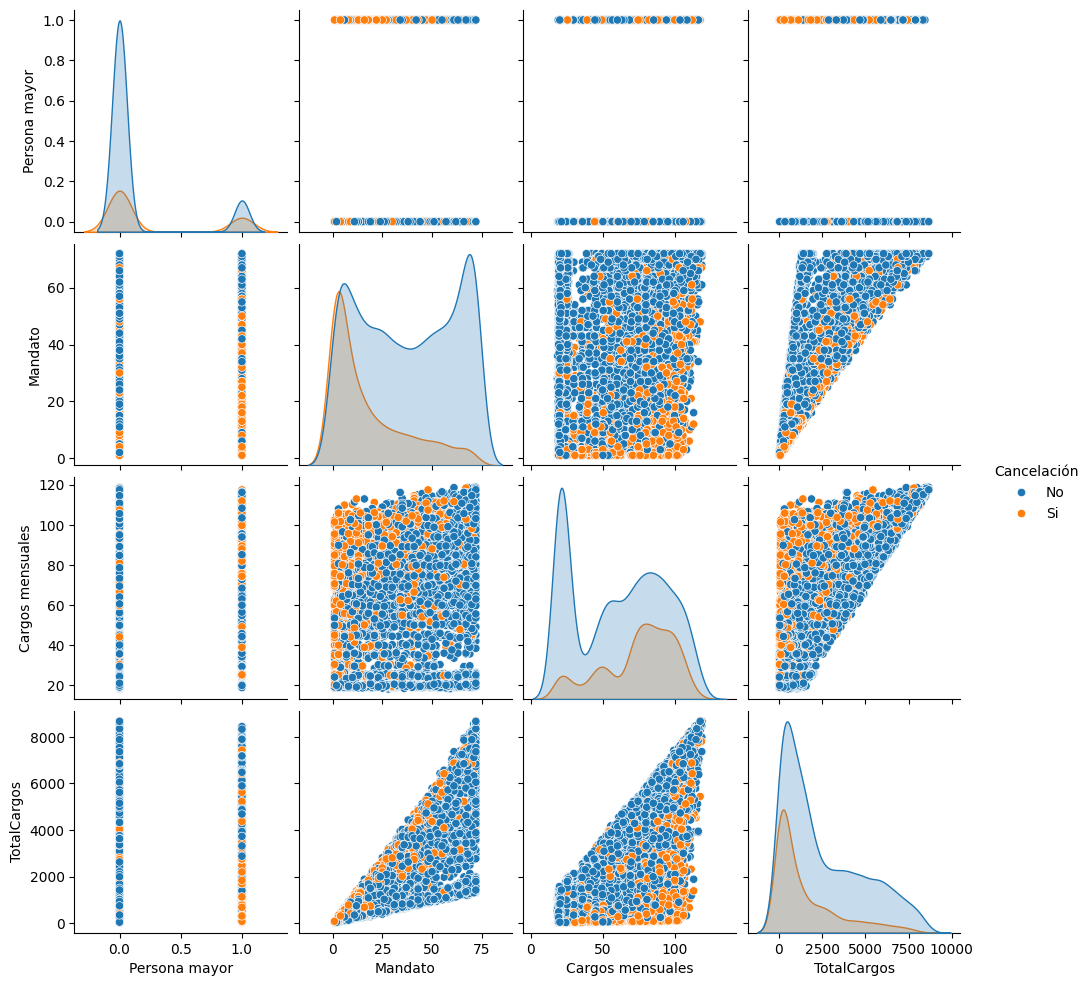

In [14]:
# Grafico de correlación
plt.figure(figsize=(10,6))
sns.pairplot(data=Data_Kaggle, hue="Cancelación")
plt.show()

### Datos Escalares

In [15]:
#Datos de escalamiento
Escalar = MinMaxScaler()
Data_Kaggle_Escalar = Escalar.fit_transform(Data_Kaggle_Int)

#DataFrame Datos escalamiento
Data_Kaggle_Escalar_DF = pd.DataFrame(Data_Kaggle_Escalar)

#Pasamos nombre de los campos al DF Escalar
Data_Kaggle_Escalar_DF.columns = Data_Kaggle_Int.columns
#Data_Kaggle_Escalar_DF


### Entrenamiento del modelo de regresión logistica

In [16]:
x = Data_Kaggle_Escalar_DF.drop("Cancelación", axis=1)
y = Data_Kaggle_Escalar_DF["Cancelación"].values

# Obtenemos Variables de entrenamiento
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.3, 
    random_state=42,
    stratify=y # Se Agrega para mejorar el modelo, estratifica los datos a partir de Cancelaciones
)

Modelo = LogisticRegression()
Modelo.fit(x_train, y_train)
Prediccion = Modelo.predict(x_test)

# Obtenemos el porentaje de exactitud de precisión del modelo
Exactitud = accuracy_score(y_test ,Prediccion)
print(f"Porcentaje de precisión del modelo: {Exactitud*100:.2f}%")

Porcentaje de precisión del modelo: 80.43%


### Evaluación y Caracteristicas del modelo

In [17]:
#Evaluación del modelo
Modelo.predict_proba(x_test)

#Caracteristicas
Modelo.feature_names_in_

pesos = pd.Series(Modelo.coef_[0], index=x.columns.values)
pesos_DF = pd.DataFrame({
    "Variable": x.columns.values,
    "Coeficiente": Modelo.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

In [18]:
pesos_DF["Color"] = pesos_DF["Coeficiente"].apply(lambda x: "Negativo" if x < 0 else "Positivo")

fig = px.bar(
    pesos_DF,
    x="Variable",
    y="Coeficiente",
    color="Color",
    color_discrete_map={"Negativo": "darkred", "Positivo": "darkblue"},
    labels={"x":"Variables", "y":"Coeficiente"},
    title="Coeficientes del Modelo (Logistic Regression)"
)

fig.update_layout(width=890, height=900)

Estilos(fig)
fig.show()

### Matriz de confusión

In [19]:
Matriz_Confucion_II = confusion_matrix(y_test, Prediccion)

# Mostrar valores en consola
print(f"Verdaderos Negativos (VN): {Matriz_Confucion_II[0][0]} Personas que NO cancelaron y el modelo dijo NO canceló.")
print(f"Verdadero Positivo (VP): {Matriz_Confucion_II[1][1]} Personas que SÍ cancelaron y el modelo dijo SÍ canceló.")
print(f"Falso Positivos (FP): {Matriz_Confucion_II[0][1]} Personas que NO cancelaron, pero el modelo dijo que SÍ cancelaron.")
print(f"Falso Negativo (FN): {Matriz_Confucion_II[1][0]} Personas que SÍ cancelaron, pero el modelo dijo que NO cancelaron.")

# Heatmap con Plotly
fig = px.imshow(
    Matriz_Confucion_II,
    text_auto=True,
    color_continuous_scale="Blues",
    labels=dict(x="Predicciones", y="Verdaderos", color="Cantidad"),
    x=["No cancela (0)", "Sí cancela (1)"],
    y=["No cancela (0)", "Sí cancela (1)"]
)

fig.update_layout(
    title="Matriz de Confusión",
    width=600,
    height=500
)

Estilos(fig)

fig.show()

Verdaderos Negativos (VN): 1382 Personas que NO cancelaron y el modelo dijo NO canceló.
Verdadero Positivo (VP): 315 Personas que SÍ cancelaron y el modelo dijo SÍ canceló.
Falso Positivos (FP): 167 Personas que NO cancelaron, pero el modelo dijo que SÍ cancelaron.
Falso Negativo (FN): 246 Personas que SÍ cancelaron, pero el modelo dijo que NO cancelaron.
